#### Imports

In [12]:
import importlib
import numpy as np
import pandas as pd
import os
from datetime import datetime
import json
from pathlib import Path

import metrics
import plots
import symbolic_features
import build_features
import train
import experiment

importlib.reload(train)
importlib.reload(symbolic_features)
importlib.reload(build_features)
importlib.reload(experiment)
importlib.reload(plots)
importlib.reload(metrics)

from experiment import simple_ablation_experiment, make_time_windows, windowed_ablation_experiment
from plots import plot_symbolic_performance_delta

In [2]:
df = pd.read_csv("../data/ait_ads/labeled_combined_ait.csv", low_memory=False)

#### Simple ablation experiment: one scenario, all symbolic features

In [3]:
run_name="1-itemset-bayes"
out_dir = f"../plots/{run_name}"
os.makedirs(out_dir, exist_ok=True)

In [13]:
window_size = pd.Timedelta(days=1)

for scenario_name, df_scenario in df.groupby("scenario", sort=False):
    # run per-scenario on the scenario slice
    res = simple_ablation_experiment(df_scenario, run_name, window_size, scenario_name=scenario_name)

    diag_base = res["diag_base"]
    diag_symbolic_all = res["diag_sym_all"]

    print("\nBASE:", diag_base)
    print("BASE+SYM:", diag_symbolic_all, "\n")

    print("BASE FEATS: ", res["base_feats"])
    print("SYM FEATS: ", res["sym_feats"])

    results_dict = {"base": res["diag_base"]}
    for feat, diag in res["diag_ablation"].items():
        results_dict[feat] = diag
    results_dict["all_symbolic"] = res["diag_sym_all"]

    plot_symbolic_performance_delta(
        results_dict,
        scenario_name=scenario_name,  
        metric="auc",
        out_dir=out_dir
    )


Running scenario = harrison (593948 alerts)
token join match rate: 0.026074962781329362
df alerts: 137028 unique ids: 136858
tok alerts: 3573 unique ids: 3555
match rate (by id): 0.026074962781329362
Built features: 6 dynamic cols, 10 static cols, 12 symbolic cols

Training BASELINE model...

Training base + 'is_mined__wazuh:is_ids_alert=1' ...

Training base + 'is_mined__wazuh:src_freq_bin=very_high' ...

Training base + 'is_mined__wazuh:dst_fanin_bin=low' ...

Training base + 'is_mined__wazuh:ids_category=PotentiallyBadTraffic' ...


KeyboardInterrupt: 

#### Score shift

No test samples where is_root_login_attempt=1
No samples for is_behavioral_novelty=1 with y=1 (attack)
No samples for is_high_severity_wazuh=1 with y=1 (attack)
No samples for is_wazuh_critical=1 with y=1 (attack)
No samples for is_ids_high_priority=1 with y=1 (attack)
No samples for is_ids_concept=1 with y=1 (attack)
No test samples where is_high_sev_and_novel=1
No test samples where is_rare_entity_then_burst=1
No test samples where is_auth_failure_then_uid0=1
No samples for is_high_sev_non_update_non_av=1 with y=1 (attack)
No samples for is_ids_category_malware_or_c2=1 with y=1 (attack)
No test samples where is_mitre_execution_or_persistence=1
No test samples where is_novel_and_ids=1
No test samples where is_auth_burst_and_ids=1
No test samples where is_auth_burst_high_ent_rate=1
No test samples where is_benign_auth_noise=1
No test samples where is_aminer_novel_but_stable=1
No test samples where is_internal_scan_like=1
No test samples where is_low_sev_ids_background=1
No test samples

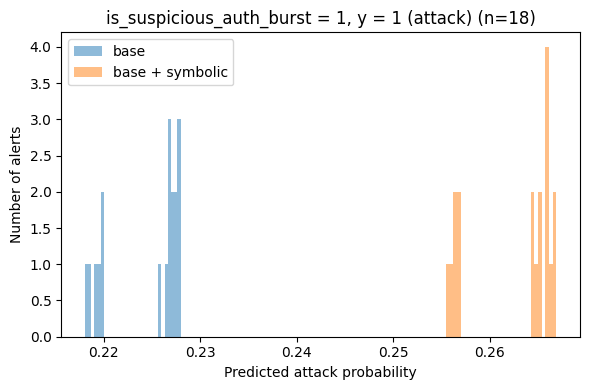

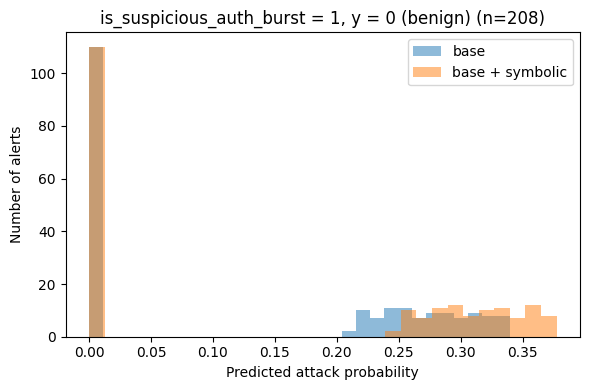

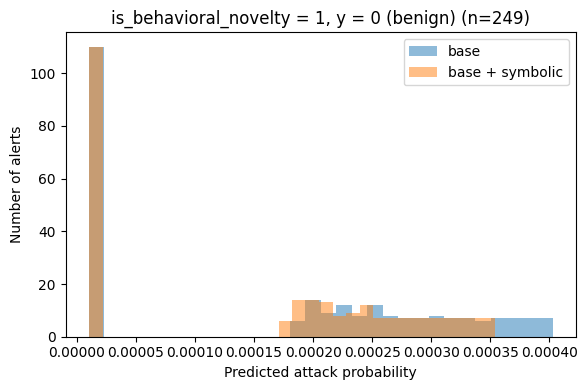

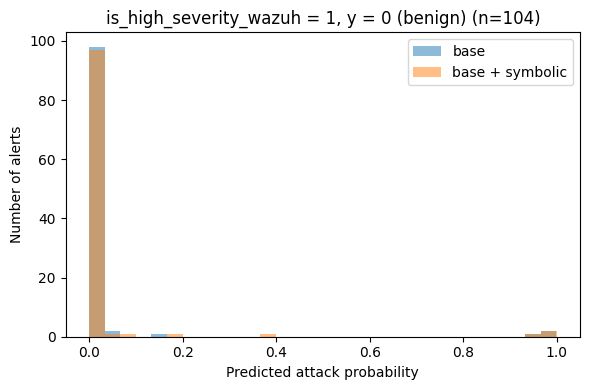

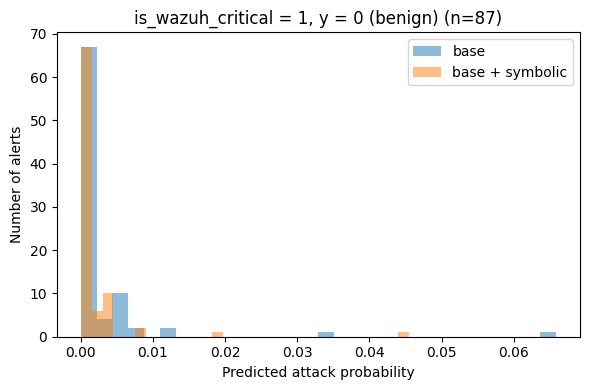

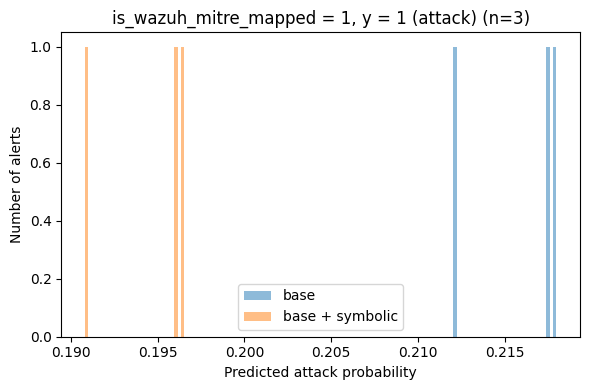

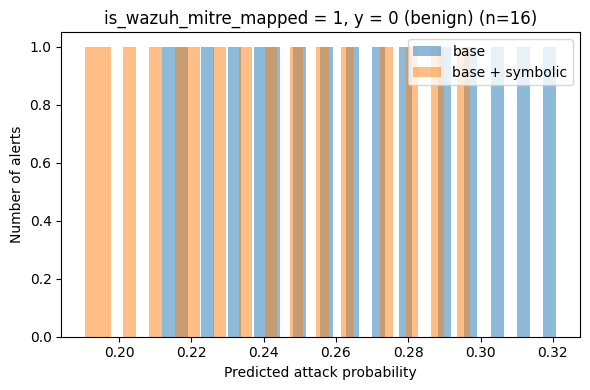

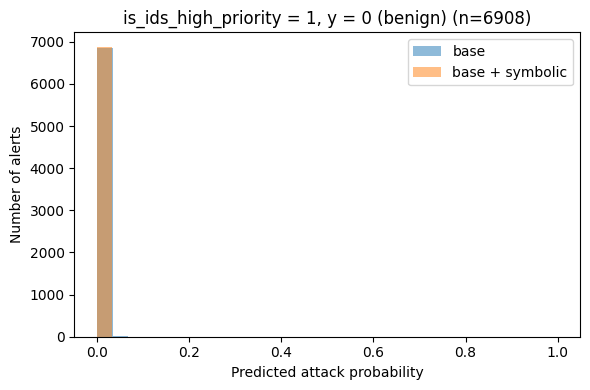

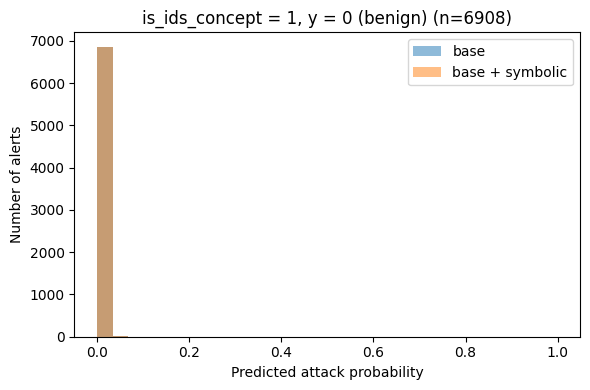

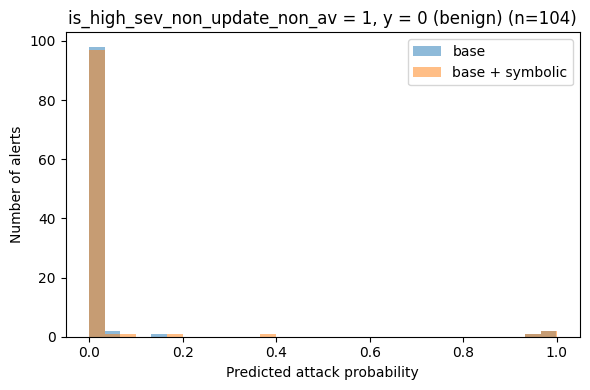

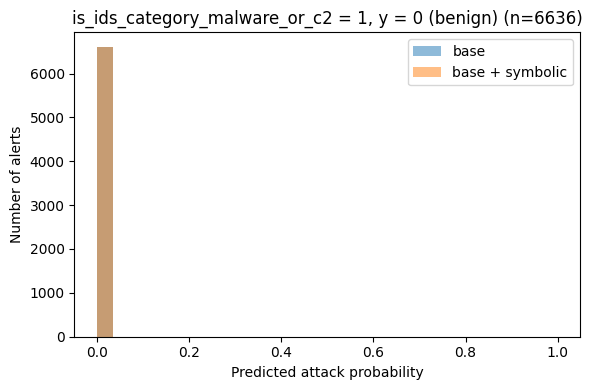

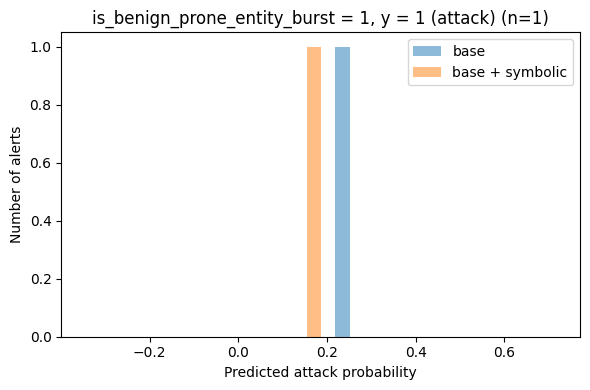

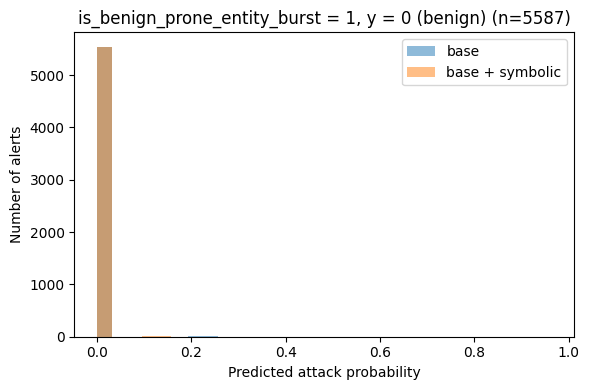

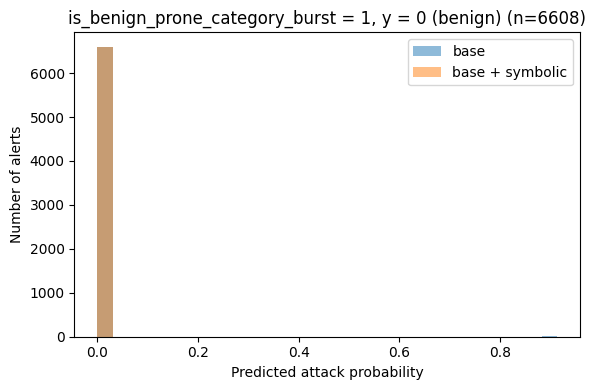

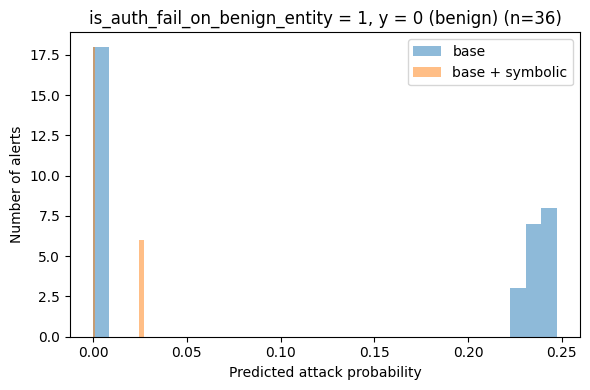

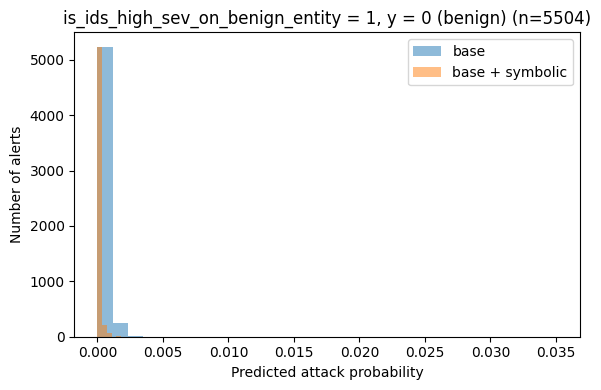

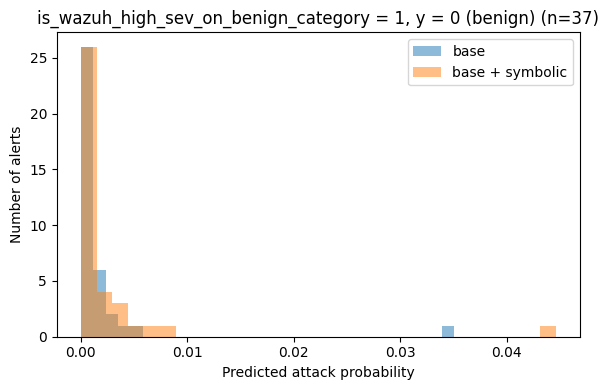

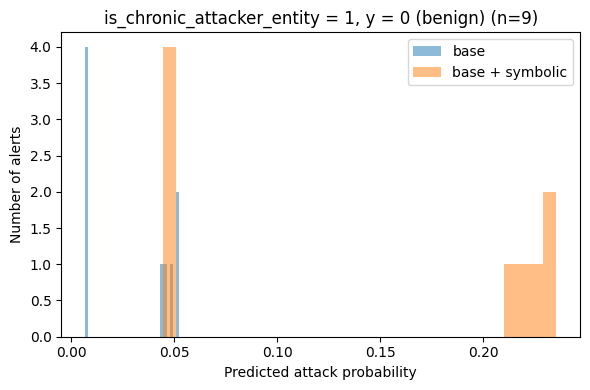

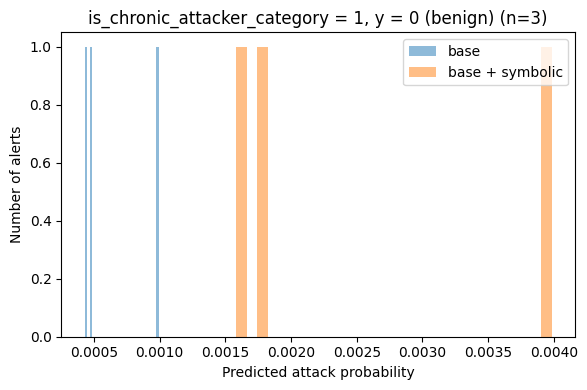

In [8]:
out_dir = os.path.join(out_dir, "ablation_score_shifts")
os.makedirs(out_dir, exist_ok=True)

for f in res["sym_feats"]:
    res_feat = res["ablation"].get(f)

    if res_feat is None:
        print(f"Skipping {f} (no ablation result)")
        continue
    
    plot_symbolic_score_shift_by_label(
        X_full=res["X_full"],
        y=res["y"],
        res_base=res["base"],
        res_sym=res_feat,         
        feature=f,
        out_dir=out_dir,
        prefix=f
    )

#### FP to TN after adding symbolic feature to base

In [5]:
rows = []

for f in res["sym_feats"]:
    res_feat = res["ablation"].get(f)
    if res_feat is None:
        continue

    stats = plot_fp_to_tn(
        X_full=res["X_full"],
        y=res["y"],
        res_base=res["base"],
        res_sym=res_feat,
        feature=f,
        threshold=0.5,
    )

    if stats is not None:
        rows.append(stats)


df_flips = pd.DataFrame(rows).sort_values(
    by=["fp_to_tn"], ascending=False
)

print(df_flips)


                                 feature  n_subset  fp_to_tn  delta_fp  \
5                   is_ids_high_priority      6908        20       -20   
8          is_ids_category_malware_or_c2      6636        12       -12   
0               is_suspicious_auth_burst       226         0         0   
1                  is_behavioral_novelty       249         0         0   
2                 is_high_severity_wazuh       104         0         0   
3                      is_wazuh_critical        87         0         0   
4                  is_wazuh_mitre_mapped        19         0         0   
6                         is_ids_concept      6908         0         1   
7          is_high_sev_non_update_non_av       104         0         0   
9           is_benign_prone_entity_burst      5588         0         0   
10        is_benign_prone_category_burst      6608         0         0   
11         is_auth_fail_on_benign_entity        36         0         0   
12      is_ids_high_sev_on_benign_enti

##### Coefficient of symbolic features in respective ablation

In [6]:
out_dir = os.path.join(out_dir, "ablation_coefficients")

os.makedirs(out_dir, exist_ok=True)

for feat in res["sym_feats"]:
    res_feat = res["ablation"].get(feat)

    if res_feat is None:
        print(f"Skipping {feat} (no ablation model)")
        continue

    plot_symbolic_coefficients(
        model=res_feat["model"],
        feature_names=res_feat["feature_names"],
        symbolic_features=[feat],   # plot for one feature
        out_dir=out_dir,
        prefix=feat
    )

coef_sym:  is_suspicious_auth_burst   -1.512363
dtype: float64
coef_sym:  is_root_login_attempt    0.0
dtype: float64
coef_sym:  is_behavioral_novelty   -2.186215
dtype: float64
coef_sym:  is_high_severity_wazuh    1.817254
dtype: float64
coef_sym:  is_wazuh_critical   -0.140646
dtype: float64
coef_sym:  is_wazuh_mitre_mapped   -1.111003
dtype: float64
coef_sym:  is_ids_high_priority   -4.458509
dtype: float64
coef_sym:  is_ids_concept    2.670577
dtype: float64
coef_sym:  is_high_sev_and_novel    0.0
dtype: float64
coef_sym:  is_rare_entity_then_burst    0.0
dtype: float64
coef_sym:  is_auth_failure_then_uid0   -0.023578
dtype: float64
coef_sym:  is_high_sev_non_update_non_av    1.817254
dtype: float64
coef_sym:  is_ids_category_malware_or_c2   -2.435341
dtype: float64
coef_sym:  is_mitre_execution_or_persistence    0.0
dtype: float64
coef_sym:  is_novel_and_ids    0.0
dtype: float64
coef_sym:  is_auth_burst_and_ids    0.0
dtype: float64
coef_sym:  is_auth_burst_high_ent_rate    1.396

### Craft time windows to cover all attacks per scenario

In [7]:
wdays = 1
sdays = 1

def check_window_coverage(df_s, wins, ts_col="timestamp"):
    df_s = df_s.copy()
    df_s[ts_col] = pd.to_datetime(df_s[ts_col], utc=True, errors="coerce")
    df_s = df_s.dropna(subset=[ts_col]).sort_values(ts_col)  # keep original index

    total_attacks = int((df_s["y"] == 1).sum())

    covered_idx = set()
    for _, _, w in wins:
        covered_idx.update(w.index)

    covered = df_s.loc[df_s.index.isin(covered_idx)]
    covered_attacks = int((covered["y"] == 1).sum())

    uncovered = df_s.loc[~df_s.index.isin(covered_idx)]
    uncovered_attacks = int((uncovered["y"] == 1).sum())

    print("total attacks:", total_attacks)
    print("covered attacks:", covered_attacks)
    print("uncovered attacks:", uncovered_attacks)
    if uncovered_attacks > 0:
        print("uncovered time range:", uncovered[ts_col].min(), "→", uncovered[ts_col].max())



df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.dropna(subset=["timestamp"])

all_windows = {}

for scenario, df_s in df.groupby("scenario"):
    df_s = df_s.sort_values("timestamp").copy()

    wins = make_time_windows(df_s, window_days=wdays, step_days=sdays)
    all_windows[scenario] = wins

    print(f"\nScenario: {scenario} | n_windows: {len(wins)}")
    for i, (s, e, w) in enumerate(wins):
        print(i, s.date(), "→", e.date(), "rows", len(w), "y", w["y"].value_counts().to_dict())
    
    check_window_coverage(df_s, wins)



Scenario: fox | n_windows: 5
0 2022-01-15 → 2022-01-16 rows 4266 y {0: 4266}
1 2022-01-16 → 2022-01-17 rows 5480 y {0: 5480}
2 2022-01-17 → 2022-01-18 rows 3843 y {0: 3841, 1: 2}
3 2022-01-18 → 2022-01-19 rows 5659 y {0: 5578, 1: 81}
4 2022-01-19 → 2022-01-19 rows 5097 y {0: 5097}
total attacks: 83
covered attacks: 83
uncovered attacks: 0

Scenario: harrison | n_windows: 5
0 2022-02-04 → 2022-02-05 rows 33008 y {0: 33008}
1 2022-02-05 → 2022-02-06 rows 28155 y {0: 28155}
2 2022-02-06 → 2022-02-07 rows 27478 y {0: 27478}
3 2022-02-07 → 2022-02-08 rows 29164 y {0: 29164}
4 2022-02-08 → 2022-02-08 rows 19223 y {0: 19151, 1: 72}
total attacks: 72
covered attacks: 72
uncovered attacks: 0

Scenario: russellmitchell | n_windows: 4
0 2022-01-21 → 2022-01-22 rows 4625 y {0: 4625}
1 2022-01-22 → 2022-01-23 rows 3865 y {0: 3865}
2 2022-01-23 → 2022-01-24 rows 5480 y {0: 5480}
3 2022-01-24 → 2022-01-24 rows 4634 y {0: 4575, 1: 59}
total attacks: 59
covered attacks: 59
uncovered attacks: 0

Scenar

## Temporal Symbolic Feature selection Experiments

#### Abalation study using FP suppression in the next time window as a feature selection objective

In [31]:
run_name = "fp_ablation_mem"
out_dir = f"../plots/{run_name}"
os.makedirs(out_dir, exist_ok=True)

use_mem = True
tau = 0.9

In [38]:
config = dict(
    run_name=run_name,
    window_days=wdays,
    step_days=sdays,
    lookback_days=1,
    test_frac=0.3,
    threshold=0.5,
    use_memory=True,
    ts=datetime.now().isoformat(timespec="seconds"),
)
with open(os.path.join(out_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")


all_rows = []

# Run experiment for each scenario
for scenario, df_s in df.groupby("scenario"):

    span_days = (df_s["timestamp"].max() - df_s["timestamp"].min()).days
    window_days = max(1, span_days // 3)
    step_days   = window_days

    scen_dir = os.path.join(out_dir, scenario)
    os.makedirs(scen_dir, exist_ok=True)

    hist = windowed_ablation_experiment(
        df=df_s,
        window_days=window_days,
        step_days=step_days,
        lookback_days=1,

        # FP only ablation settings
        use_memory=use_mem,
        tau=tau,
        force_fp_only=True,
        fp_min_support=200
    )

    # save per-scenario
    with open(os.path.join(scen_dir, "history.json"), "w") as f:
        json.dump(hist, f, indent=2, default=str)

    # also collect for aggregate comparisons
    for row in hist:
        row = dict(row)
        row["scenario"] = scenario
        all_rows.append(row)

# save aggregate (easy to load/concat later)
with open(os.path.join(out_dir, "all_history.jsonl"), "w") as f:
    for row in all_rows:
        f.write(json.dumps(row, default=str) + "\n")

k – index of the sliding window iteration

train_window – time range used to train + select symbolic features

active_syms – symbolic features selected in that window (kept for next window)

auc_train_base – baseline model AUC inside the training window

auc_next – performance when applied to the next window (generalization)

alerts_next – number of alerts raised in next window (threshold = 0.5)

fp_next – false positives in next window

fn_next – missed attacks in next window

In [39]:
hist_df = pd.DataFrame(hist)
hist_df.head()

print(hist_df.columns)

Index(['k', 'mode', 'scenario', 'train_window', 'selected_syms', 'tau',
       'mem_scores_selected', 'supports_k', 'suppression_base',
       'suppression_per_feat', 'suppression_all_or'],
      dtype='object')


#### FP Suppression rate per scenario

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/plots.py:616: FutureWarning: The provided callable <function sum at 0x1119b0680> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/plots.py:616: FutureWarning: The provided callable <function sum at 0x1119b0680> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.


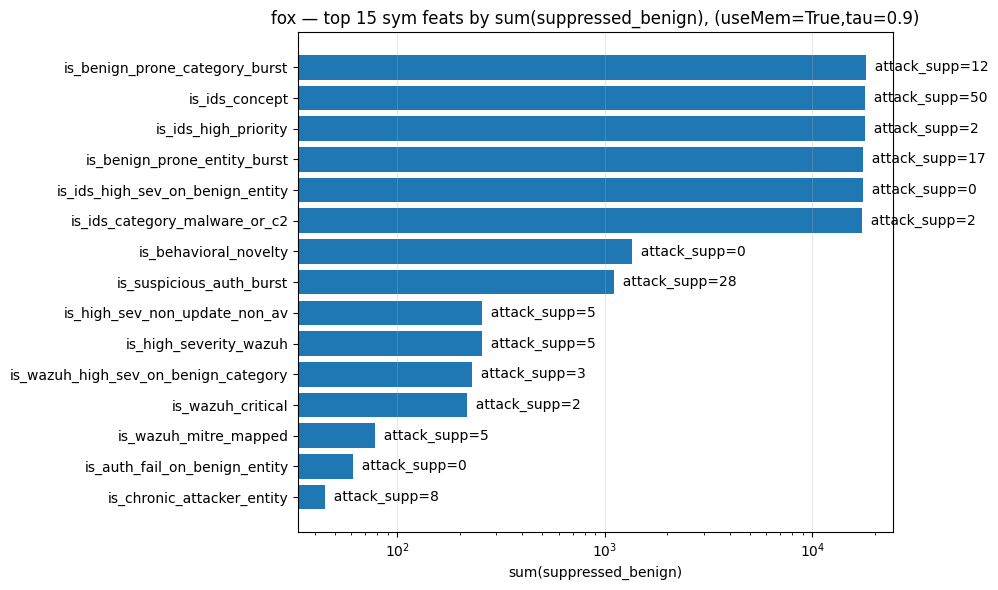

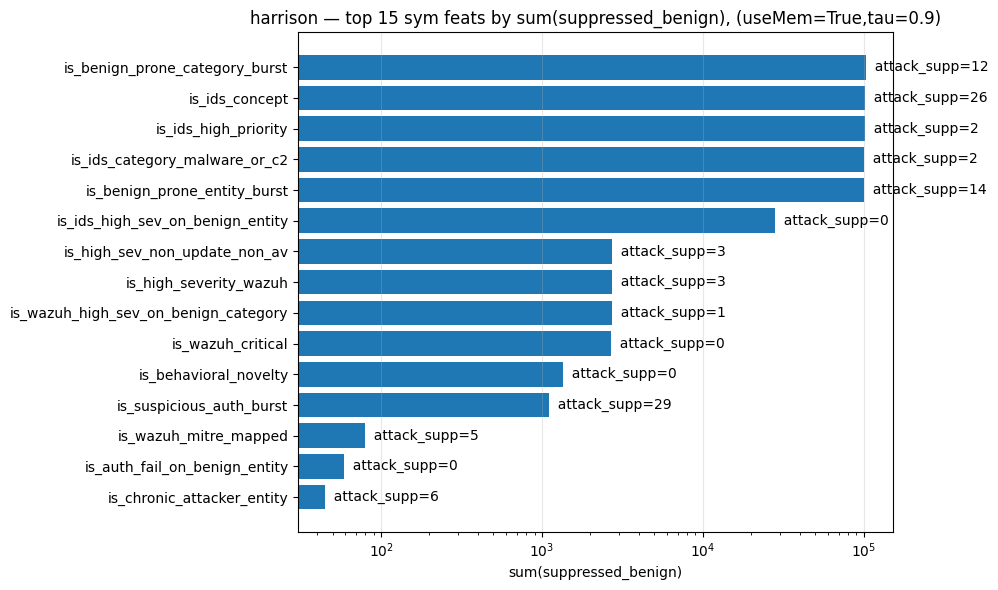

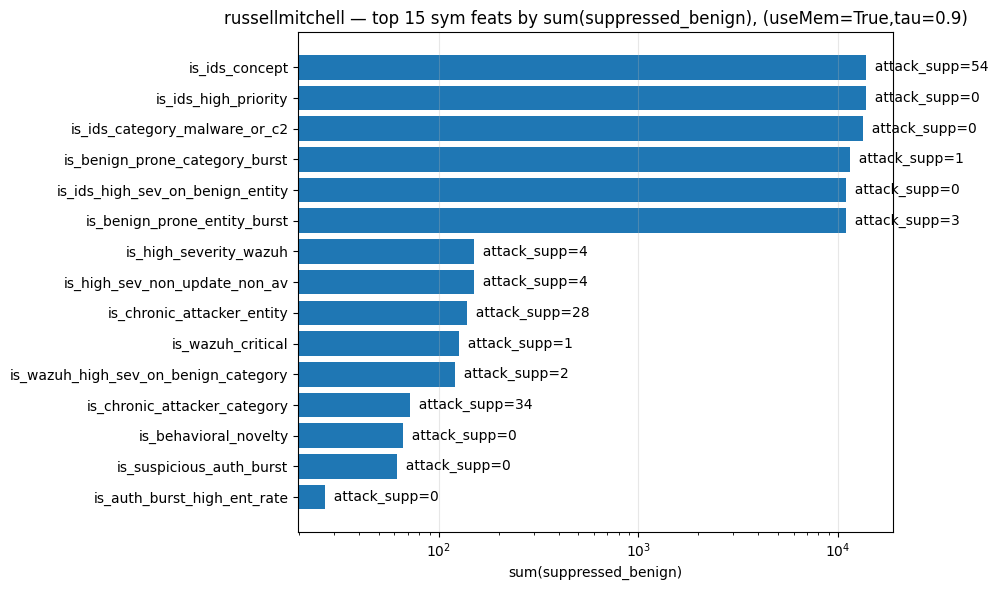

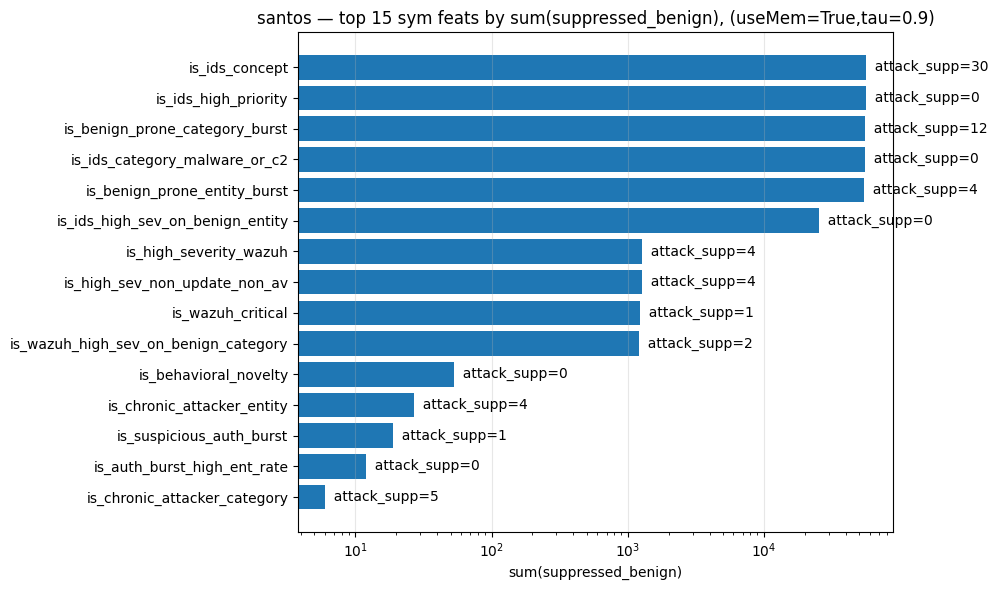

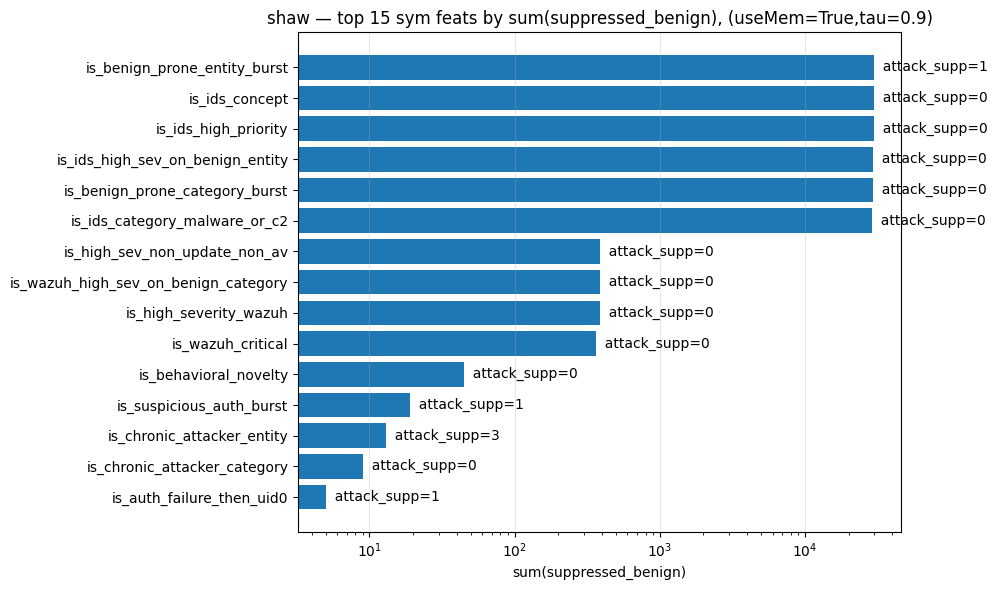

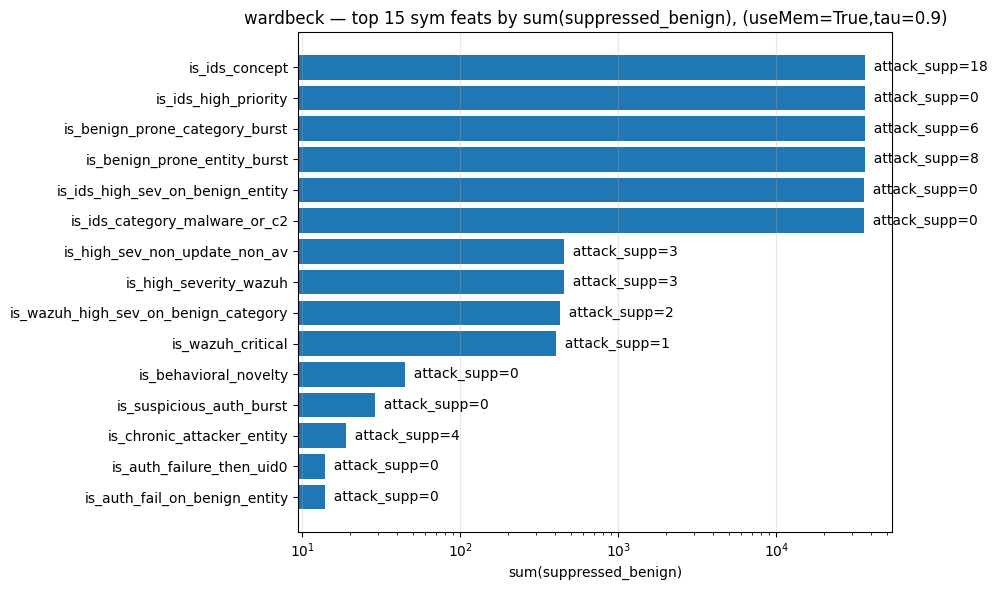

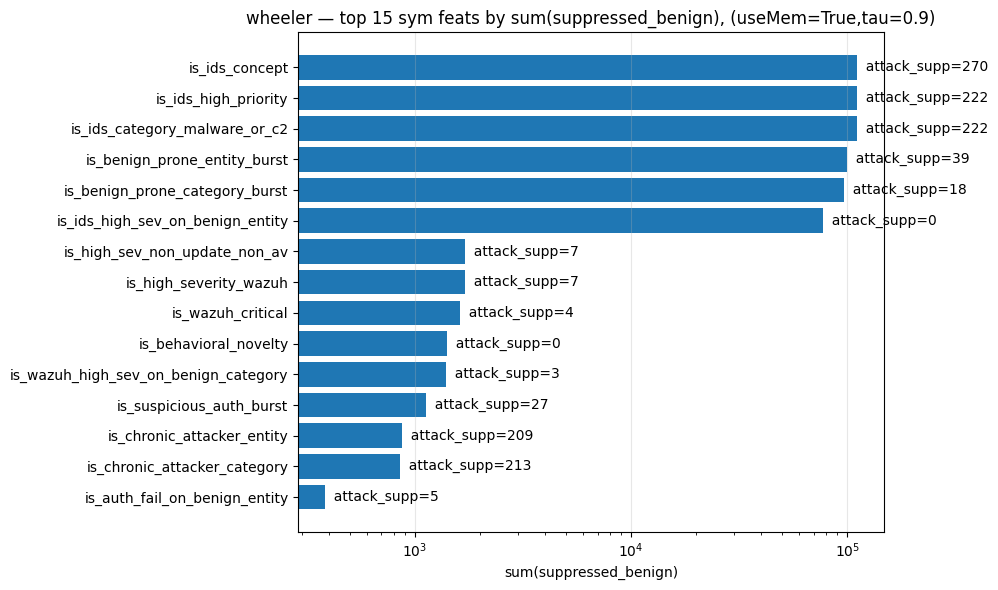

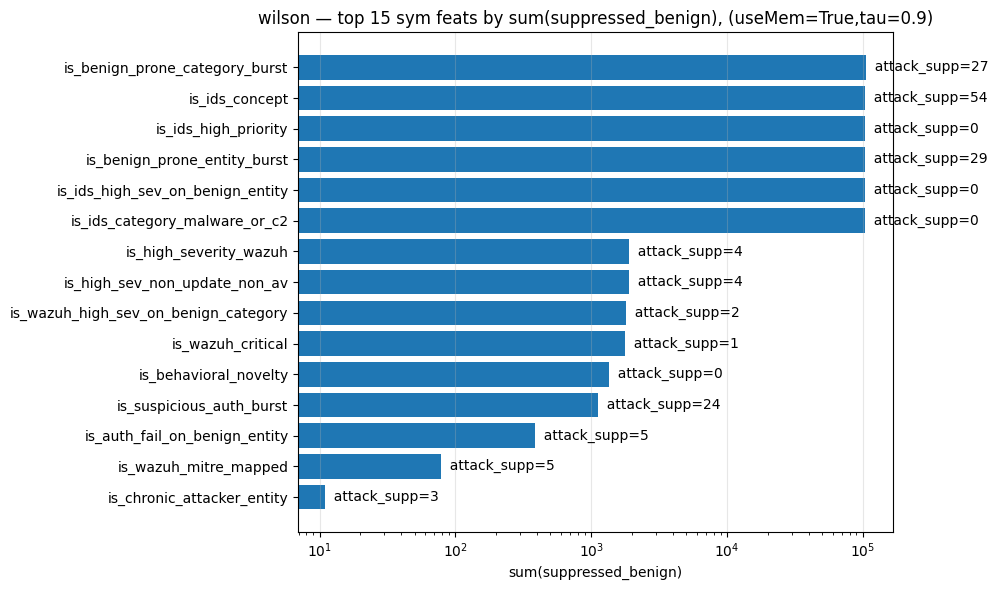

In [40]:
long, summary = plot_fp_only_feature_suppression(
    os.path.join(out_dir, "all_history.jsonl"),
    out_dir,
    use_mem,
    tau,
    topk=15,
    metric="suppressed_benign",  # best default
    agg="sum",
)

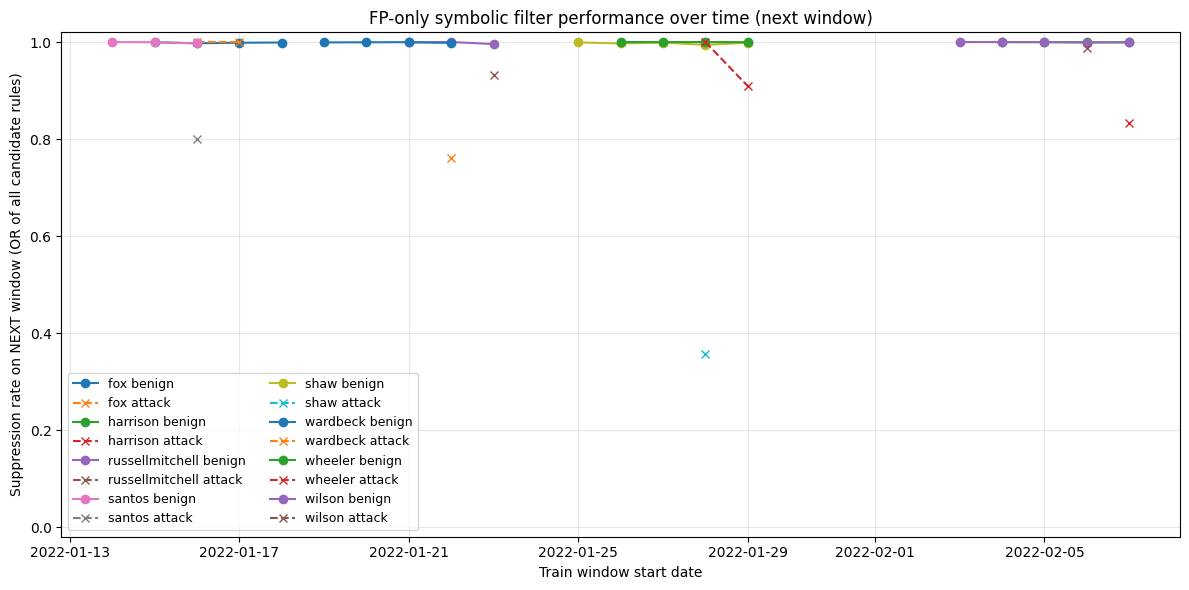

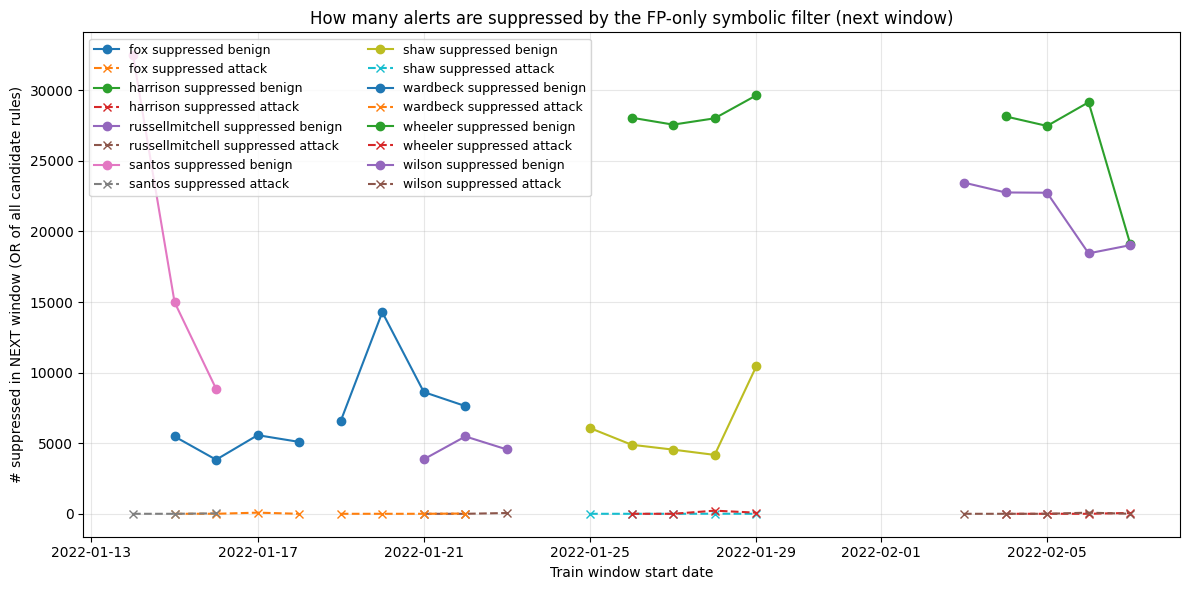

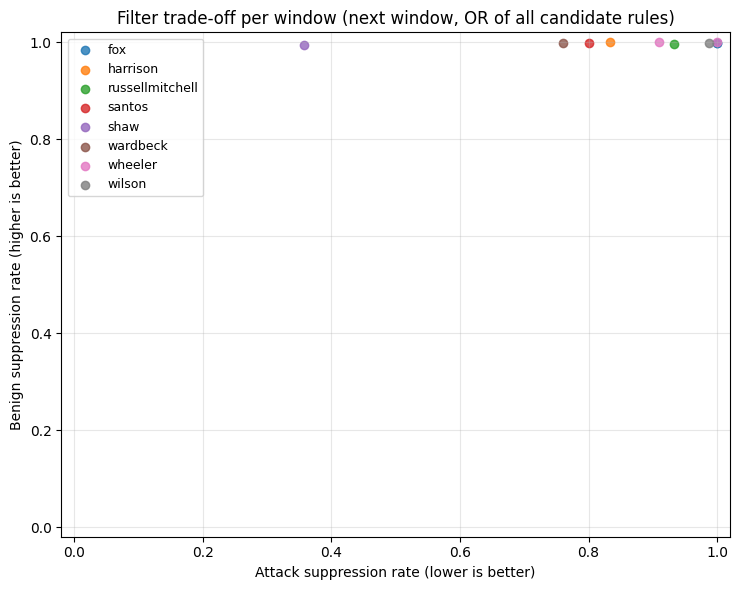

In [41]:
JSONL_PATH = Path(os.path.join(out_dir, "all_history.jsonl"))
df_raw = load_fp_only_history_jsonl(str(JSONL_PATH))
df_prepped = prepare_fp_only_window_metrics(df_raw)
plot_suppression_rates(df_prepped)
plot_suppressed_counts(df_prepped)
plot_tradeoff_scatter(df_prepped)


Saving plot to ../plots/fp_ablation_mem/suppression/fox...
Saving plot to ../plots/fp_ablation_mem/suppression/harrison...
Saving plot to ../plots/fp_ablation_mem/suppression/russellmitchell...
Saving plot to ../plots/fp_ablation_mem/suppression/santos...
Saving plot to ../plots/fp_ablation_mem/suppression/shaw...
Saving plot to ../plots/fp_ablation_mem/suppression/wardbeck...
Saving plot to ../plots/fp_ablation_mem/suppression/wheeler...
Saving plot to ../plots/fp_ablation_mem/suppression/wilson...


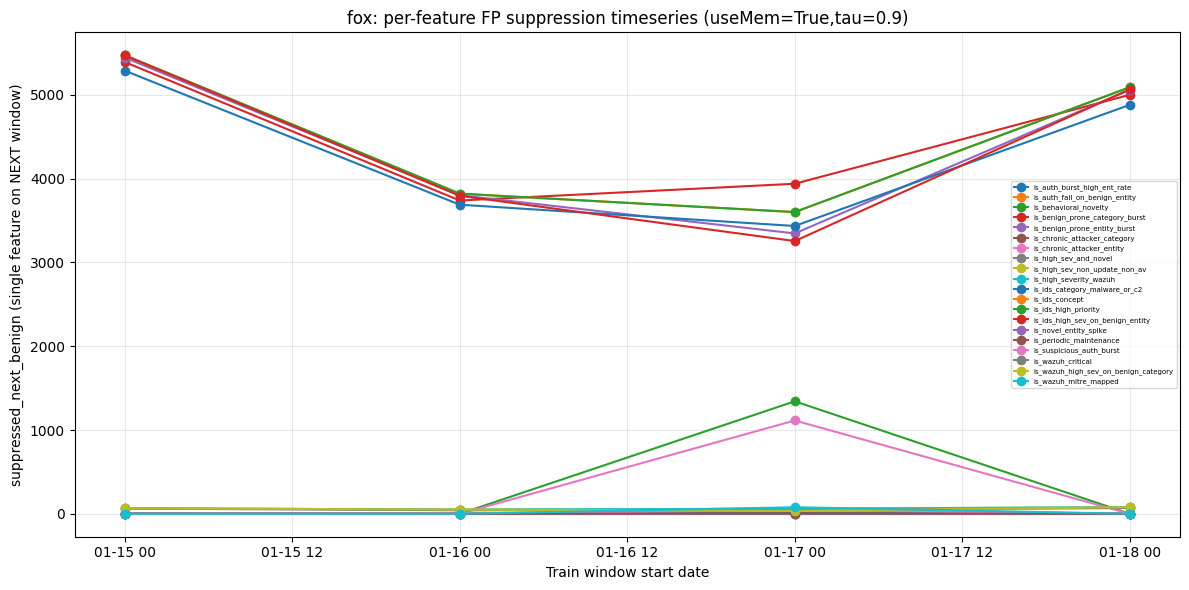

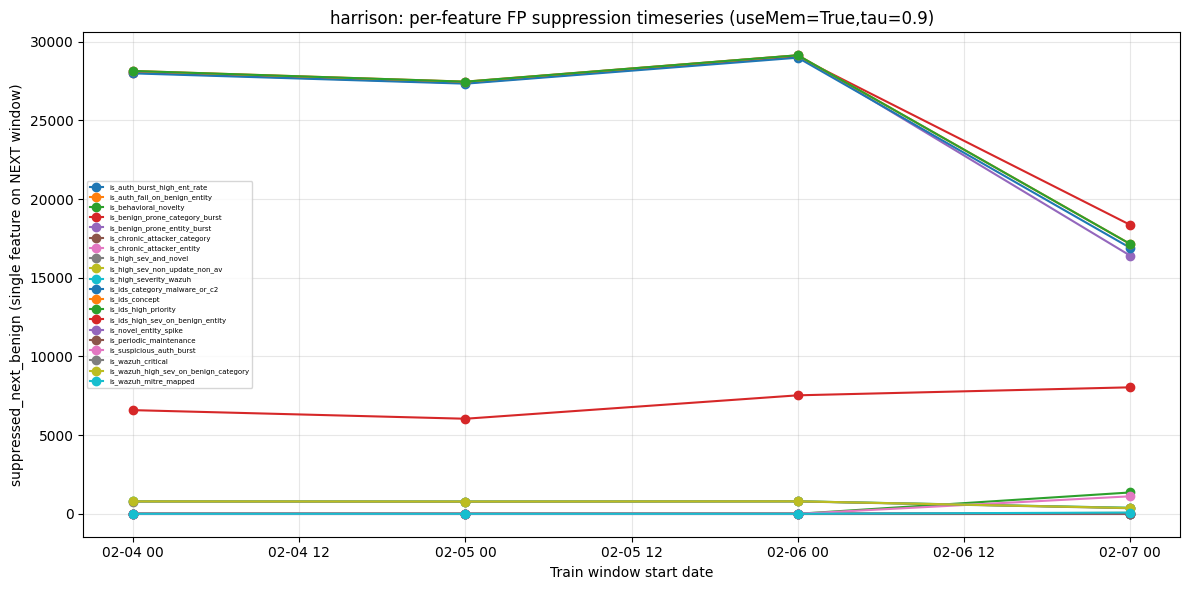

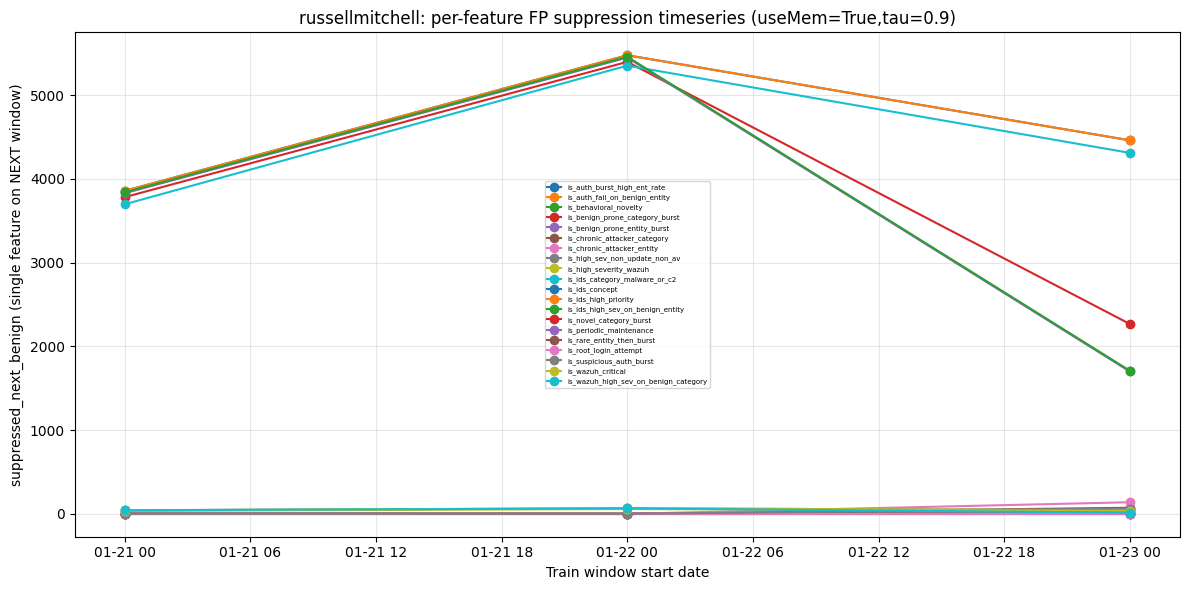

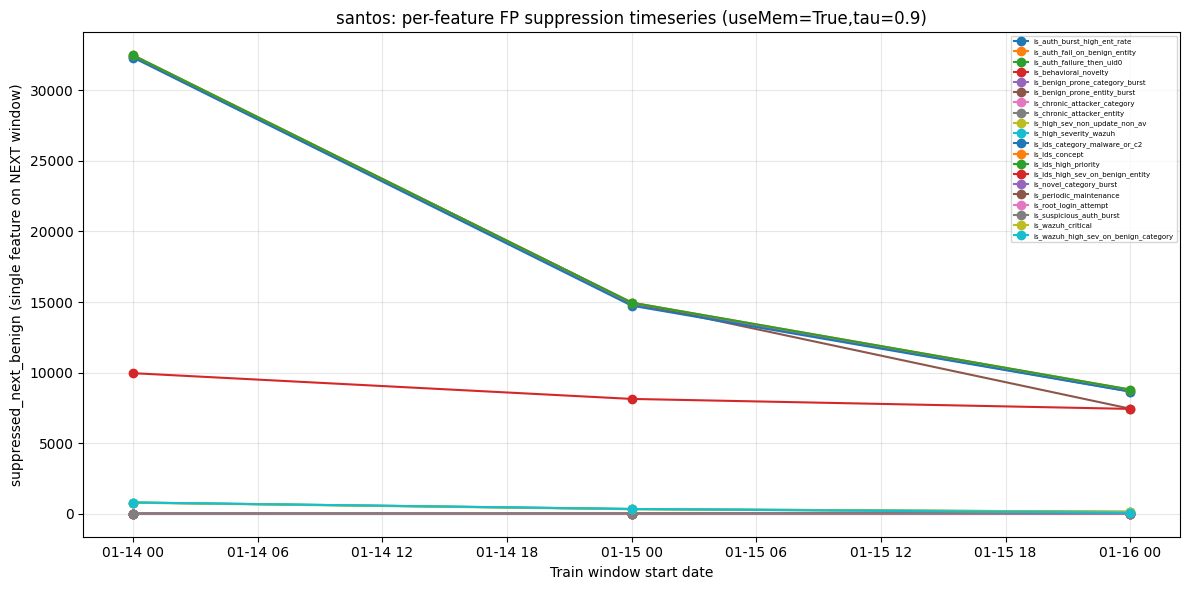

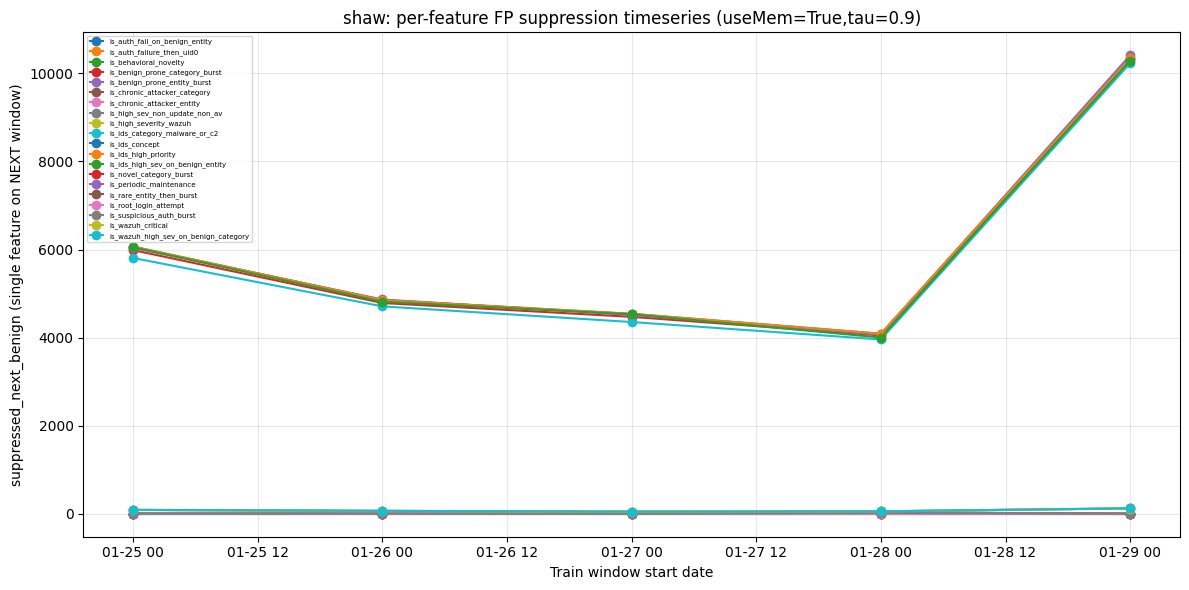

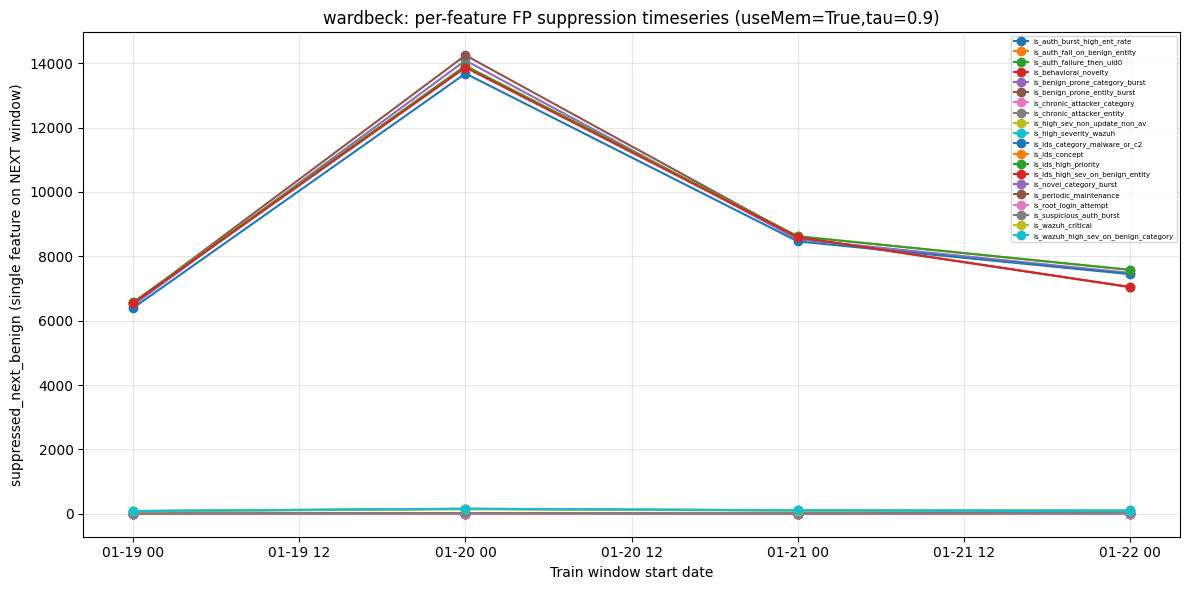

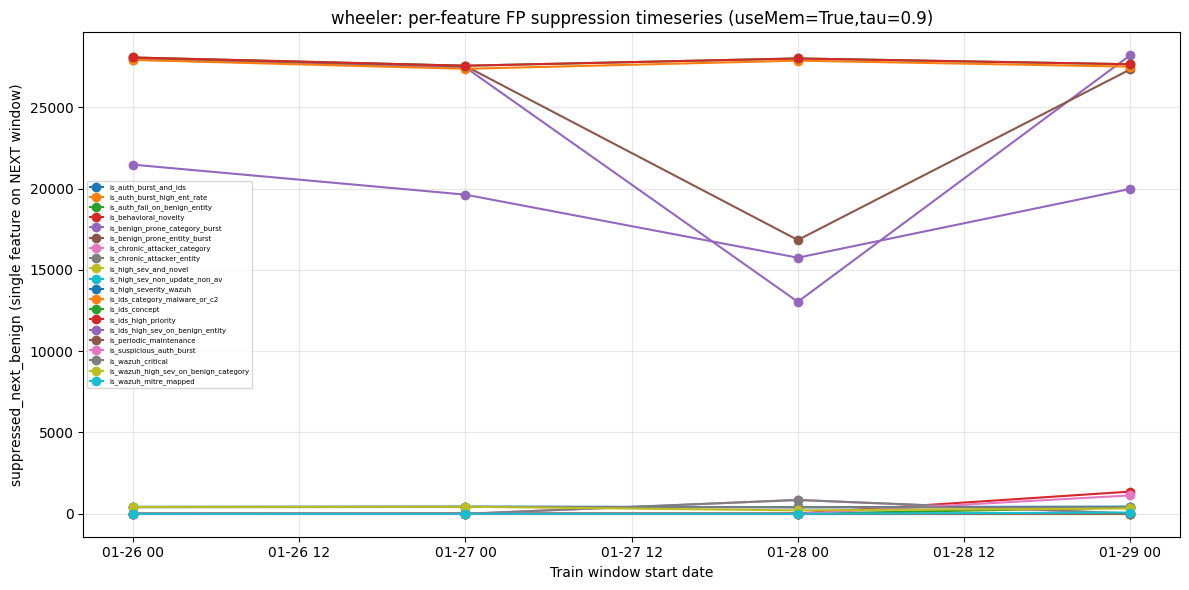

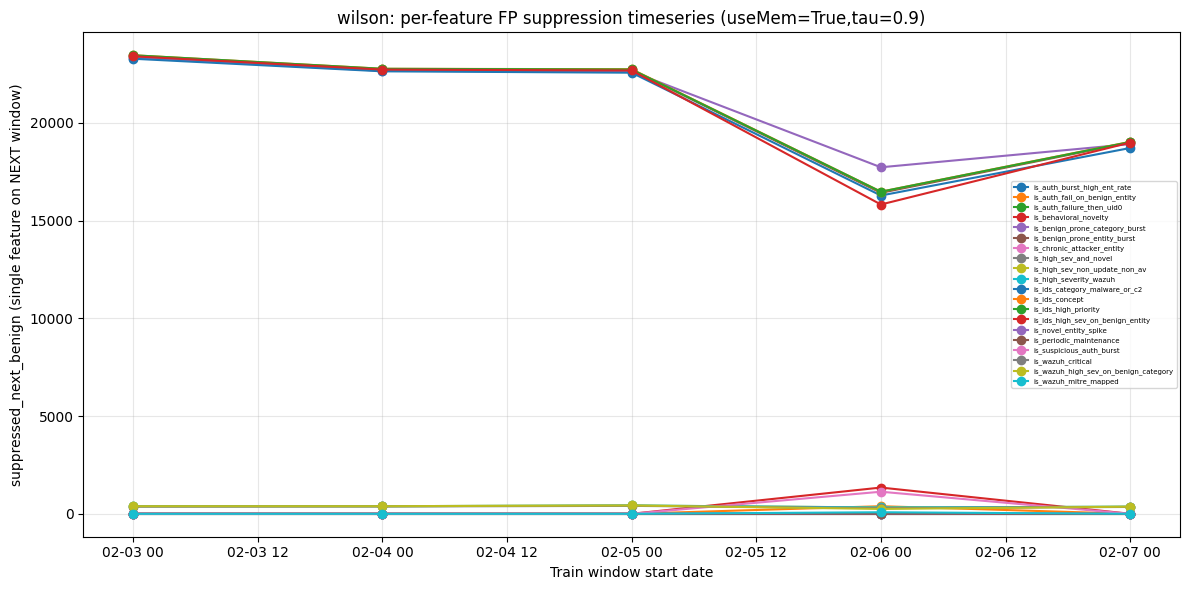

In [42]:
output_dir = os.path.join(out_dir, "suppression")
os.makedirs(output_dir, exist_ok=True)


for scen in df.groupby("scenario"):
    plot_per_feature_fp_suppression_timeseries(JSONL_PATH, use_memory=use_mem, tau=tau, scenario_name=scen[0], out_dir=output_dir, topk=20)